<style>
  body {
    margin: 0;
    padding: 0;
    font-family: Arial, sans-serif;
  }

  /* Linha das logos usando table layout */
  .cover-header {
    display: table;
    width: 100%;
    margin-top: 20px;
    table-layout: fixed;
  }

  .cover-header .left{
    display: table-cell;
    width: 20%;
    vertical-align: middle;
    text-align: center;
  }
  .cover-header .right {
    display: table-cell;
    width: 30%;
    vertical-align: middle;
    text-align: center;
  }

  .cover-header .center {
    display: table-cell;
    width: 50%;
    text-align: center;
    vertical-align: middle;
  }

  .cover-header img {
    max-height: 55px;
    width: auto;
    display: inline-block;
  }

  /* Texto institucional embaixo das logos */
  .cover-center {
    text-align: center;
    margin-top: 20px;
    vertical-align: middle;
  }

  .cover-center p {
    text-align: center;
    vertical-align: middle;
    margin: 0;
    font-weight: 700;
    line-height: 1.4;
    font-size: 16px;
  }

  /* Título e autor */
  .cover-title {
    margin-top: 120px;
    text-align: center;
  }

  .cover-title h1 {
    font-size: 28px;
    margin-bottom: 60px;
  }

  .cover-title .author {
    font-size: 18px;
    margin-top: 160px; /* nome bem mais abaixo */
  }

  /* Rodapé fixo */
  .cover-footer {
    position: absolute;
    bottom: 30px;
    left: 0;
    width: 100%;
    text-align: center;
    font-size: 14px;
  }

  .cover-footer {
  position: absolute;
  bottom: 30px;
  left: 0;
  width: 100%;
  text-align: center;
  font-size: 14px;
}

</style>

<div class="cover-header">
  <div class="left">
    <img src="Imagens/logo_virtus2.png" alt="Logo VIRTUS">
  </div>
  <div class = "center"></div>
  <div class="right">
    <img src="Imagens/logo_ufcg.png" alt="Logo UFCG">
  </div>
</div>

<div class="cover-center">
  <p>
    UNIVERSIDADE FEDERAL DE CAMPINA GRANDE<br>
    CENTRO DE CIÊNCIAS E TECNOLOGIA<br>
    CENTRO DE ENGENHARIA ELÉTRICA E INFORMÁTICA<br>
    CENTRO DE COMPETÊNCIAS EMBRAPII VIRTUS-CC
  </p>
</div>

<div class="cover-title">
  <h1>Transceptores Digitais</h1>
  <p class="author">Jezrael Pereira Filgueiras</p>
</div>

<div class="cover-footer">
  Campina Grande, 12 de abril de 2026
</div>

<div style="page-break-after: always;"></div>

# 1 Introdução

# 2 Desenvolvimento

## 2.1 Transmissor 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray
from optic.comm.metrics import bert
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm
from optic.utils import parameters, dBm2W
from scipy.special import erfc

In [28]:
SpS = 16
M = [2, 4, 8, 16]  
Rs = 10e8  
Fs = SpS * Rs

paramBits = parameters()
paramBits.nBits = 240000
paramBits.mode = 'random' 
paramBits.seed = 42

paramPulse = parameters()
paramPulse.pulseType = 'nrz'  
paramPulse.SpS = SpS

In [29]:
bits = bitSource(paramBits)
pulse = pulseShape(paramPulse)
signalsTx = []
for i in range(len(M)):  
    symbols = modulateGray(bits, M[i], constType = 'pam')
    sigTx = upsample(symbols, SpS)
    sigTx = firFilter(pulse, sigTx)
    signalsTx.append(sigTx)

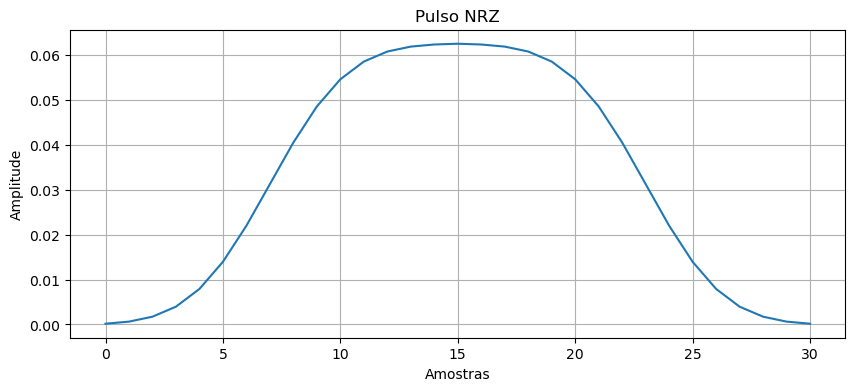

In [31]:
# Plot do pulso utilizado
plt.figure(figsize=(10, 4))
plt.plot(pulse)
plt.xlabel('Amostras')
plt.ylabel('Amplitude')
plt.title('Pulso NRZ')
plt.grid(True)
plt.show()

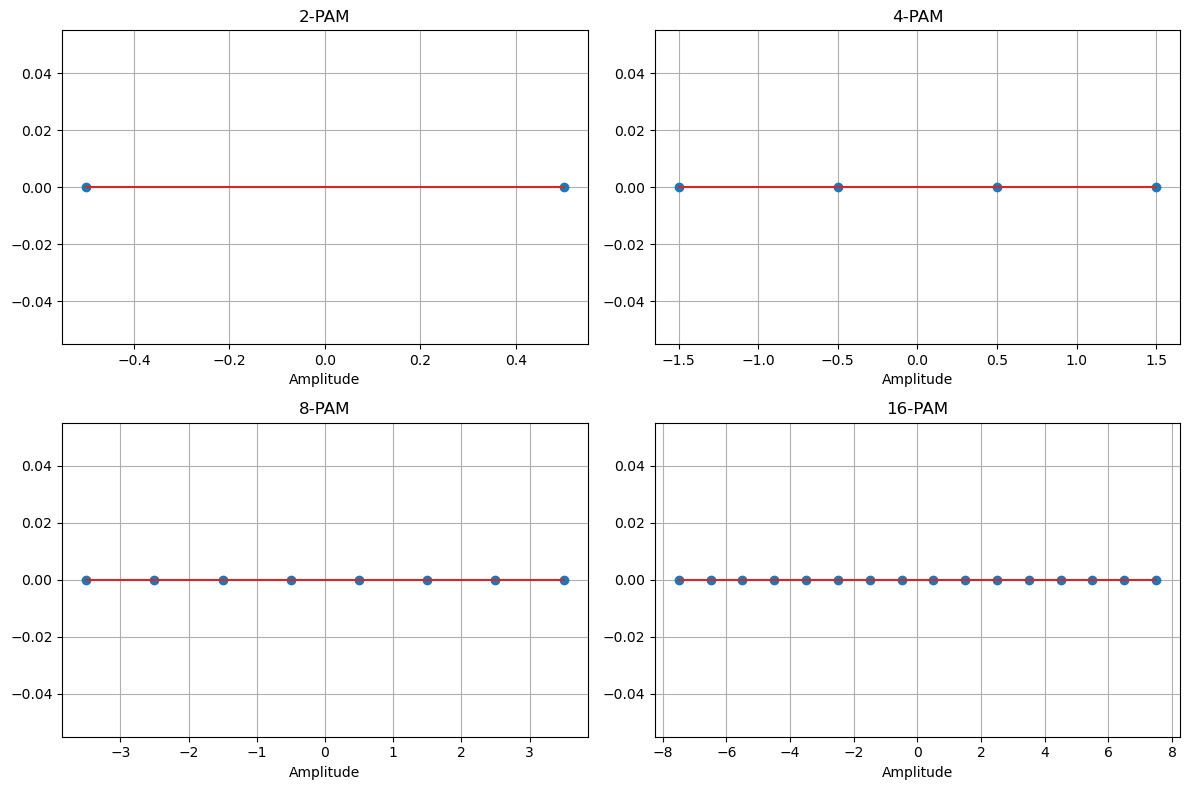

In [34]:
# Plot das constelações 2-PAM, 4-PAM, 8-PAM e 16-PAM
plt.figure(figsize=(12, 8))
for i in range(len(M)):
    plt.subplot(2, 2, i + 1)
    constellation = np.arange(M[i]) - (M[i] - 1) / 2
    plt.stem(constellation, np.zeros_like(constellation))
    plt.xlabel('Amplitude')
    plt.title(f'{M[i]}-PAM')
    plt.grid(True)

plt.tight_layout()
plt.show()

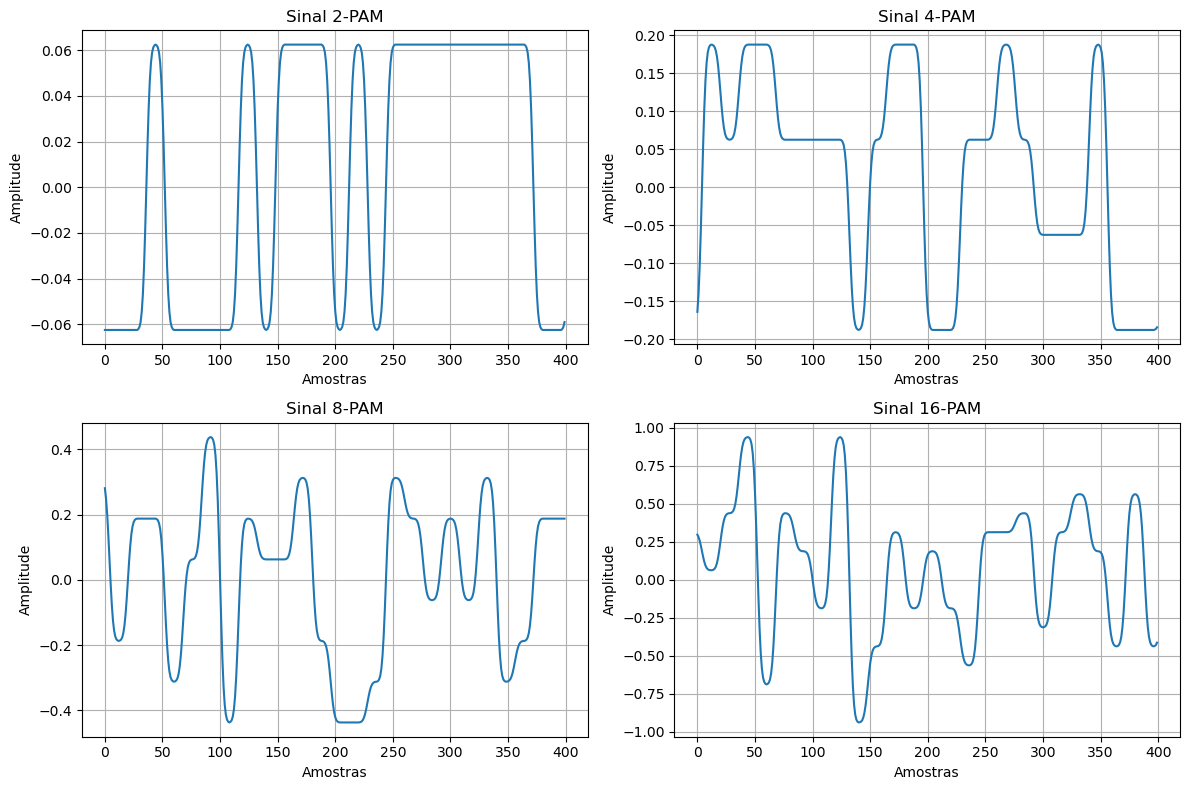

In [37]:
# Plot dos sinais transmitidos
plt.figure(figsize=(12, 8))
for i in range(len(M)):
    plt.subplot(2, 2, i + 1)
    plt.plot(signalsTx[i][100:500])
    plt.xlabel('Amostras')
    plt.ylabel('Amplitude')
    plt.title(f'Sinal {M[i]}-PAM')
    plt.grid(True)
plt.tight_layout()
plt.show()

## 2.2 Canal

## 2.3 Receptor